# Week 3: 동적 응답 예측과 rollout

공정 예측과 최적화를 위한 서로게이트 모델링 · Sunwoo Kim

현재 상태와 주어진 미래 온도 계획에서 전체 농도 궤적을 예측한다. 같은 저장 모델을 one-step과 rollout으로 평가한다. 실습 묶음을 풀고 이 Notebook을 그 폴더에서 실행한다. 필요한 패키지는 `requirements.txt`에 있다.

Prediction task: initial composition + prescribed future temperature inputs → 30 min concentration trajectory.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cstr_transition as cstr
from week03_lab import evaluate


## 1. 첫 상태전이 계산

330 K, τ = 5 min, feed = 1.2 mol/L. Δt = 0.2 min. 변화량의 단위는 mol/L다. / Compute the first interval response.

In [2]:
initial = np.array([[1.2, 0., 0.]])
control = np.array([[330., 5., 1.2]])
next_state = cstr.reference_step(initial, control)
print("Next state, mol/L:", next_state[0])
print("Increment, mol/L:", (next_state-initial)[0])
print("Sum:", next_state.sum())


Next state, mol/L: [1.15386981e+00 4.56720112e-02 4.58180965e-04]
Increment, mol/L: [-0.04613019  0.04567201  0.00045818]
Sum: 1.2000000000000002


## 2. 독립 궤적 평가

One-step에는 매 시각 기준 상태를 넣는다. Rollout에는 앞선 예측을 넣는다. / Evaluate the same frozen model in both protocols.

In [3]:
metrics, trajectories, predictions = evaluate(Path("week03-results"))


{
  "one_step": {
    "rmse_mol_L": [
      0.0011698733687232174,
      0.0012881459751205937,
      0.0011631600085516736
    ],
    "balance_rmse_mol_L": 5.1329873751630126e-05,
    "minimum_predicted_concentration_mol_L": -0.001152203213085274
  },
  "rollout": {
    "rmse_mol_L": [
      0.009465025357851294,
      0.009629144427021242,
      0.010425194376398996
    ],
    "balance_rmse_mol_L": 0.002013982987355719,
    "minimum_predicted_concentration_mol_L": -0.00516641000457166
  },
  "trajectory_counts": {
    "train": 60,
    "validation": 15,
    "test": 20
  },
  "transition_counts": {
    "train": 9000,
    "validation": 2250,
    "test": 3000
  },
  "dt_min": 0.2,
  "horizon_min": 30.0,
  "evaluation": "same frozen model; reference versus predicted current states"
}


## 3. 전체 궤적과 horizon별 오차

온도 계획은 주어진다. 초기 상태 뒤에는 기준 농도를 rollout에 주입하지 않는다. / Compare trajectories and error versus horizon.

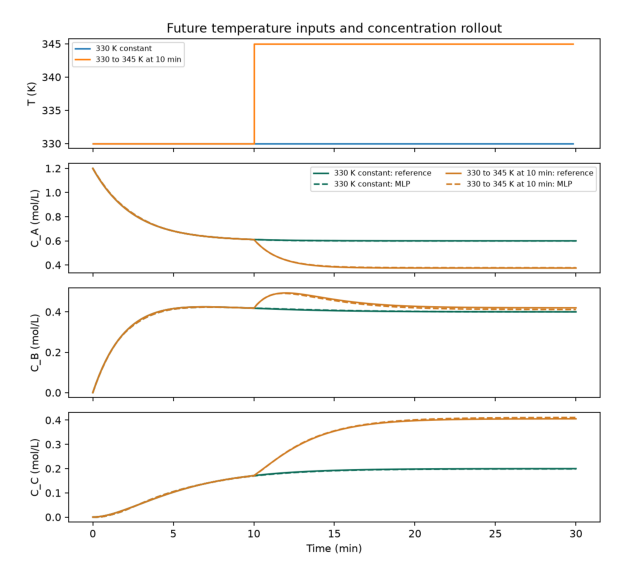

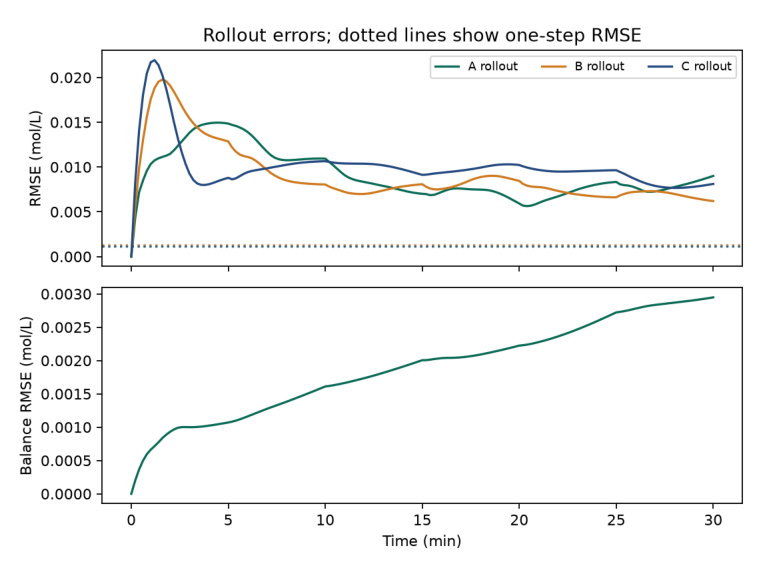

In [4]:
for name in ["dynamic-rollout.png", "dynamic-errors.png"]:
    plt.figure(figsize=(10, 6))
    plt.imshow(plt.imread(Path("week03-results") / name))
    plt.axis("off")
    plt.show()


## 4. 초기 상태만 바꾸기

입력 계획을 유지하며 초기 상태를 [0.2, 0.8, 0.2]로 바꾼다. / Keep the future inputs fixed and change the initial state.

{'rmse_mol_L': [0.0066709338814699435, 0.0049788177951477965, 0.004695674747638106], 'balance_rmse_mol_L': 0.0006589654977454142, 'minimum_predicted_concentration_mol_L': 0.19912686245379493}


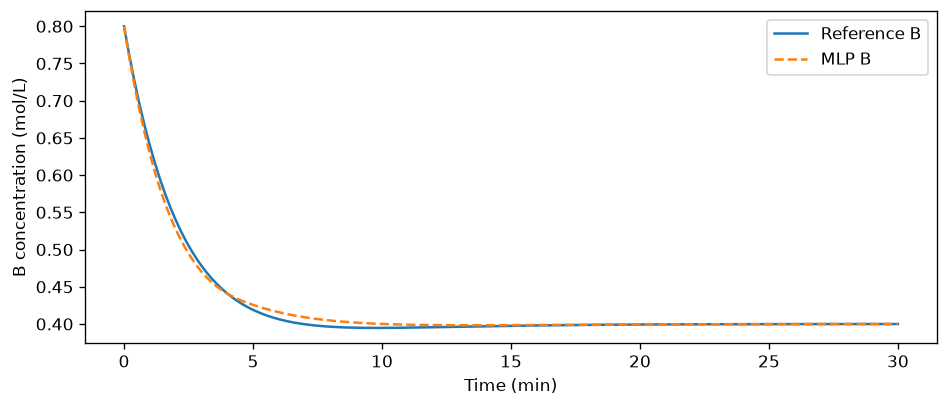

In [5]:
model, scaling = cstr.load_model(Path("."), "dynamic-model")
controls = np.tile([330., 5., 1.2], (150, 1))
new_initial = np.array([.2, .8, .2])
reference = cstr.simulate_trajectory(controls, new_initial)
predicted = cstr.rollout(model, scaling, controls, new_initial)
print(cstr.prediction_metrics(reference[1:], predicted[1:], controls[:, 2]))
plt.figure(figsize=(8, 3.5))
plt.plot(np.arange(151)*.2, reference[:, 1], label="Reference B")
plt.plot(np.arange(151)*.2, predicted[:, 1], "--", label="MLP B")
plt.xlabel("Time (min)")
plt.ylabel("B concentration (mol/L)")
plt.legend()
plt.tight_layout()
plt.show()


## 제출 / Submission

상태·입력·context·단위를 명시한다. 분할과 scaling, one-step·rollout 성분 RMSE, horizon별 오차, 두 온도 계획의 전체 궤적을 보고한다. 초기 상태를 바꾼 결과도 확인한다.

Include the state/input contract, split/scaling, both component RMSEs, horizon diagnostics, and full trajectories. RNN/LSTM and encoder–decoder are optional.
